<a href="https://colab.research.google.com/github/shadmanr1/Milestone_1/blob/main/Week_2_Notebook_Shadman_Raakin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import (LinearRegression,Ridge,Lasso,ElasticNet)
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (mean_squared_error,mean_absolute_error,r2_score)

# Dataset: Movie Box office (2000-2024)
General overview of the dataset is that it provides a detailed analysis of global box office performance from 2000 to 2024. It includes information on movies released during this period, covering key metrics such as release dates, genres, production budgets, worldwide gross, and more. The dataset aims to assist researchers, data scientists, and movie enthusiasts in exploring trends in the film industry, analyzing profitability, and understanding audience preferences over the years.
https://www.kaggle.com/datasets/aditya126/movies-box-office-dataset-2000-2024?select=enhanced_box_office_data%282000-2024%29u.csv

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving enhanced_box_office_data(2000-2024)u.csv to enhanced_box_office_data(2000-2024)u.csv


In [ ]:
df = pd.read_csv("enhanced_box_office_data(2000-2024)u.csv")
df.head()

,Rank,Release Group,$Worldwide,$Domestic,Domestic %,$Foreign,Foreign %,Year,Genres,Rating,Vote_Count,Original_Language,Production_Countries
0,1,Mission: Impossible II,546388108.0,215409889.0,39.4,330978219.0,60.6,2000,"Adventure, Action, Thriller",6.126/10,6741.0,en,United States of America
1,2,Gladiator,460583960.0,187705427.0,40.8,272878533.0,59.2,2000,"Action, Drama, Adventure",8.217/10,19032.0,en,"United Kingdom, United States of America"
2,3,Cast Away,429632142.0,233632142.0,54.4,196000000.0,45.6,2000,"Adventure, Drama",7.663/10,11403.0,en,United States of America
3,4,What Women Want,374111707.0,182811707.0,48.9,191300000.0,51.1,2000,"Comedy, Romance",6.45/10,3944.0,en,"United Kingdom, United States of America"
4,5,Dinosaur,349822765.0,137748063.0,39.4,212074702.0,60.6,2000,"Animation, Family, Adventure",6.544/10,2530.0,en,United States of America


In [ ]:
df = df.dropna()

In [ ]:
df = df.rename(columns={'$Worldwide':'Worldwide_Revenue'})
y = df['Worldwide_Revenue']

In [ ]:
df['Rating'] = (df['Rating'].str.replace('/10','').astype(float))

In [ ]:
X = df[['Year','Rating','Vote_Count']]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

###Ridge

In [ ]:
ridge_params = {'alpha': [0.01, 0.1, 1, 10, 100]}
ridge = GridSearchCV( Ridge(),ridge_params,cv=5)
ridge.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.01, 0.1, 1, 10, 100]})

In [ ]:
from sklearn.metrics import r2_score

In [ ]:
best_ridge = ridge.best_estimator_
pred_ridge = best_ridge.predict(X_test_scaled)

train_pred = best_ridge.predict(X_train_scaled)

print("Train R²:", r2_score(y_train, train_pred))
print("Test R²:", r2_score(y_test, pred_ridge))
print("Best Alpha:", ridge.best_params_)
print("R2:",r2_score(y_test, pred_ridge))
print("RMSE:",np.sqrt(mean_squared_error(y_test, pred_ridge)))

Train R²: 0.5379893239195893
Test R²: 0.5009586203637288
Best Alpha: {'alpha': 10}
R2: 0.5009586203637288
RMSE: 141184127.3292223


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(


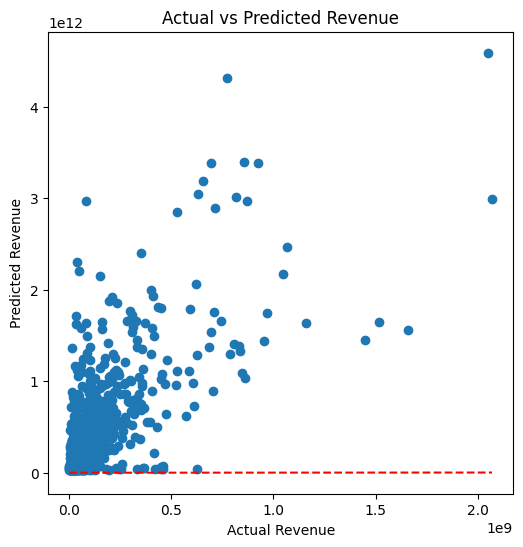

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, best_ridge.predict(X_test))
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],'r--')
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted Revenue")

plt.show()

In [ ]:
coef_df = pd.DataFrame({"Feature": X.columns,"Coefficient": best_ridge.coef_})
print(coef_df)

      Feature   Coefficient
0        Year  1.615421e+07
1      Rating -1.120613e+07
2  Vote_Count  1.523325e+08


In [ ]:
cv = ridge.cv_results_
print(ridge.best_score_)

0.5355442964774559


##Lasso

In [ ]:
lasso_params = {'alpha': [0.001, 0.01, 0.1, 1]}
lasso = GridSearchCV(Lasso(max_iter=10000),lasso_params,cv=5)
lasso.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=Lasso(max_iter=10000),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1]})

In [ ]:
best_lasso = lasso.best_estimator_
pred_lasso = best_lasso.predict(X_test_scaled)

In [ ]:
train_pred = best_lasso.predict(X_train_scaled)

print("Train R²:", r2_score(y_train, train_pred))
print("Test R²:", r2_score(y_test, pred_lasso))
print("Best Alpha:", lasso.best_params_)
print("R2:",r2_score(y_test, pred_lasso))
print("RMSE:",np.sqrt(mean_squared_error(y_test, pred_lasso)))

Train R²: 0.5379938356620295
Test R²: 0.5011078904165788
Best Alpha: {'alpha': 1}
R2: 0.5011078904165788
RMSE: 141163010.70526516


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Lasso was fitted without feature names
  warnings.warn(


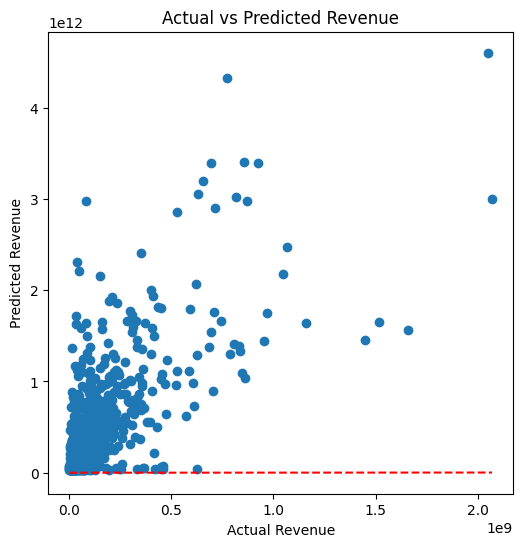

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, best_lasso.predict(X_test))
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],'r--')
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted Revenue")

plt.show()

In [ ]:
coef_df = pd.DataFrame({"Feature": X.columns,"Coefficient": best_lasso.coef_})
print(coef_df)

      Feature   Coefficient
0        Year  1.622774e+07
1      Rating -1.139022e+07
2  Vote_Count  1.527877e+08


CV Score

In [ ]:
cv = lasso.cv_results_
print(lasso.best_score_)

0.5355220395930296


## Elastic net

In [ ]:
enet_params = {'alpha': [0.001, 0.01, 0.1, 1],'l1_ratio': [0.2, 0.5, 0.8]}
enet = GridSearchCV(ElasticNet(max_iter=10000),enet_params,cv=5)
enet.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=ElasticNet(max_iter=10000),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1],
                         'l1_ratio': [0.2, 0.5, 0.8]})

In [ ]:
best_enet = enet.best_estimator_
pred_enet = best_enet.predict(X_test_scaled)

In [ ]:
train_pred = best_enet.predict(X_train_scaled)

print("Train R²:", r2_score(y_train, train_pred))
print("Best Parameters:",enet.best_params_)
print("R2:",r2_score(y_test, pred_enet))
print("RMSE:",np.sqrt(mean_squared_error(y_test, pred_enet)))

Train R²: 0.5379519127750455
Best Parameters: {'alpha': 0.01, 'l1_ratio': 0.2}
R2: 0.5006285269187233
RMSE: 141230813.08797288


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but ElasticNet was fitted without feature names
  warnings.warn(


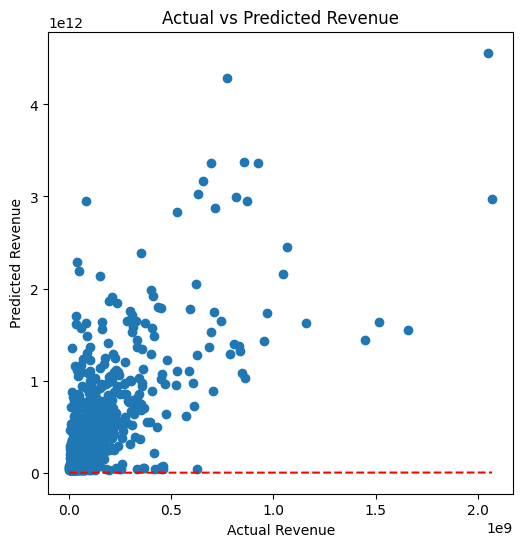

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, best_enet.predict(X_test))
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],'r--')
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted Revenue")

plt.show()

Coefficients

In [ ]:
coef_df = pd.DataFrame({"Feature": X.columns,"Coefficient": best_enet.coef_})
print(coef_df)

      Feature   Coefficient
0        Year  1.600427e+07
1      Rating -1.083146e+07
2  Vote_Count  1.513998e+08


CV Score

In [ ]:
cv = enet.cv_results_
print(enet.best_score_)

0.535550943673883


Summary table:

In [ ]:
results = pd.DataFrame({
    "Model": ["Ridge", "Lasso", "Elastic Net"],
    "Best Parameters": [
        ridge.best_params_,
        lasso.best_params_,
        enet.best_params_
    ],
    "Train R2": [
        r2_score(y_train, best_ridge.predict(X_train_scaled)),
        r2_score(y_train, best_lasso.predict(X_train_scaled)),
        r2_score(y_train, best_enet.predict(X_train_scaled))
    ],
    "Test R2": [
        r2_score(y_test, pred_ridge),
        r2_score(y_test, pred_lasso),
        r2_score(y_test, pred_enet)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, pred_ridge)),
        np.sqrt(mean_squared_error(y_test, pred_lasso)),
        np.sqrt(mean_squared_error(y_test, pred_enet))
    ],
    "CV Score": [
        ridge.best_score_,
        lasso.best_score_,
        enet.best_score_
    ]
})

In [ ]:
results["Train R2"] = results["Train R2"].round(3)
results["Test R2"] = results["Test R2"].round(3)
results["CV Score"] = results["CV Score"].round(3)
results["RMSE"] = (results["RMSE"] / 1_000_000).round(2)

results = results.rename(columns={
    "RMSE": "RMSE ($M)"
})

results

,Model,Best Parameters,Train R2,Test R2,RMSE ($M),CV Score
0,Ridge,{'alpha': 10},0.538,0.501,141.18,0.536
1,Lasso,{'alpha': 1},0.538,0.501,141.16,0.536
2,Elastic Net,"{'alpha': 0.01, 'l1_ratio': 0.2}",0.538,0.501,141.23,0.536


In [ ]:
coef_table = pd.DataFrame({
    "Feature": X.columns,
    "Ridge": best_ridge.coef_,
    "Lasso": best_lasso.coef_,
    "Elastic Net": best_enet.coef_
})

coef_table

,Feature,Ridge,Lasso,Elastic Net
0,Year,1.615421e+07,1.622774e+07,1.600427e+07
1,Rating,-1.120613e+07,-1.139022e+07,-1.083146e+07
2,Vote_Count,1.523325e+08,1.527877e+08,1.513998e+08


The analysis including ridge regression, lasso regression, and elastic net regression were shown to examine which movie characteristics (in this case, Year, Rating, Vote Count) best predict the box office revenue. Given the results with the best parameter, R2 score and RSME, the three regression models gave us almost identical predicitive performance, suggesting that the selceted predictors didn't suffer much from multicollinearity, and the regularization had a small effect on the model accuracy.